<a href="https://colab.research.google.com/github/binhminh276/hcmc-house-price_prediction/blob/main/notebooks/11_Models/02_Model_price_prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 1 Import thư viện

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from sklearn.linear_model import Ridge

df = pd.read_csv('kmeans_clustered_full.csv', sep=';', decimal = ',')

# 2 Làm sạch dữ liệu cơ bản

In [3]:
cols_to_drop = ['ID', 'Ngày hết hạn', 'Khoảng giá']
df = df.drop(columns=cols_to_drop)
print(f"Số lượng mẫu trước khi lọc: {df.shape[0]}")

df = df[df['Diện tích'] >= 10]

df = df[df['Giá m2'] <= 1.5]

df = df[df['Giá m2'] >= 0.005]

print(f"Số lượng mẫu sau khi lọc: {df.shape[0]}")
df.to_csv('cleaned_kmeans_clustered_full.csv', index=False)

Số lượng mẫu trước khi lọc: 11249
Số lượng mẫu sau khi lọc: 11230


# 3. Feature Engineering

In [4]:
def feature_engineering(data):
    df_fe = data.copy()

    # 1. Phân khúc diện tích
    bins = [0, 30, 120, np.inf]
    labels = ['Duoi_30', 'Tu_30_den_120', 'Tren_120']
    df_fe['Phan_khuc_dien_tich'] = pd.cut(df_fe['Diện tích'], bins=bins, labels=labels)

    # 2. Tỷ lệ Phòng tắm / Phòng ngủ
    df_fe['Ty_le_Bath_Bed'] = df_fe['Số phòng tắm, vệ sinh'] / (df_fe['Số phòng ngủ'] + 1e-5)

    # 3. Đặc trưng tương tác
    df_fe['Loai_hinh_Quan'] = df_fe['Cao tầng'].astype(str) + '_' + df_fe['Quận']

    # 4. Gom nhóm tiện ích thành Category
    df_fe['Tong_tien_ich'] = df_fe['Gần bệnh viện'] + df_fe['Gần chợ'] + df_fe['Gần trường học']
    df_fe['Tong_tien_ich'] = df_fe['Tong_tien_ich'].astype(str)
    df_fe = df_fe.drop(columns=['Gần bệnh viện', 'Gần chợ', 'Gần trường học'])

    df_fe['Cluster'] = df_fe['Cluster'].astype(str)

    return df_fe

df_processed = feature_engineering(df)

# 4. Phân chia tập dữ liệu & Khai báo Pipeline tiền xử lý

In [5]:
X = df_processed.drop(columns=['Giá m2'])
y = np.log1p(df_processed['Giá m2'])

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

cat_cols = ['Pháp lý', 'Nội thất', 'Quận', 'Phan_khuc_dien_tich', 'Loai_hinh_Quan', 'Tong_tien_ich', 'Cluster', 'Phường']
num_cols = ['Diện tích', 'Số phòng ngủ', 'Số phòng tắm, vệ sinh', 'Ty_le_Bath_Bed', 'Mặt tiền', 'Cao tầng', 'Quy hoạch']

preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), num_cols),
        ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), cat_cols)
    ])

# 5. Mô hình 1 - Random Forest Regressor

In [6]:
rf_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1))
])

rf_pipeline.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  ['Diện tích', 'Số phòng ngủ',
                                                   'Số phòng tắm, vệ sinh',
                                                   'Ty_le_Bath_Bed', 'Mặt tiền',
                                                   'Cao tầng', 'Quy hoạch']),
                                                 ('cat',
                                                  OneHotEncoder(handle_unknown='ignore',
                                                                sparse_output=False),
                                                  ['Pháp lý', 'Nội thất',
                                                   'Quận',
                                                   'Phan_khuc_dien_tich',
                                                   'Loai_hinh_Quan',
                                                   'Tong_tien_ich', 'Cluster',
                                                   'Phường'])])),
                ('model', RandomForestRegressor(n_jobs=-1, random_state=42))])

# 6. Mô hình 2 - XGBoost Regressor

In [7]:
xgb_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', XGBRegressor(n_estimators=100, learning_rate=0.1, random_state=42, n_jobs=-1))
])

xgb_pipeline.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  ['Diện tích', 'Số phòng ngủ',
                                                   'Số phòng tắm, vệ sinh',
                                                   'Ty_le_Bath_Bed', 'Mặt tiền',
                                                   'Cao tầng', 'Quy hoạch']),
                                                 ('cat',
                                                  OneHotEncoder(handle_unknown='ignore',
                                                                sparse_output=False),
                                                  ['Pháp lý', 'Nội thất',
                                                   'Quận',
                                                   'Phan_khuc_dien_tich',
                                                   'Loai_hinh_Quan',
                                                   'Tong_tien_ich', 'Cluster',
                                                   'Phường']...
                              feature_types=None, feature_weights=None,
                              gamma=None, grow_policy=None,
                              importance_type=None,
                              interaction_constraints=None, learning_rate=0.1,
                              max_bin=None, max_cat_threshold=None,
                              max_cat_to_onehot=None, max_delta_step=None,
                              max_depth=None, max_leaves=None,
                              min_child_weight=None, missing=nan,
                              monotone_constraints=None, multi_strategy=None,
                              n_estimators=100, n_jobs=-1,
                              num_parallel_tree=None, ...))])

#8. Đánh giá & So sánh mô hình

In [8]:
def evaluate_model(name, pipeline, X_test, y_test):
    y_pred_log = pipeline.predict(X_test)
    y_pred = np.expm1(y_pred_log)
    y_true = np.expm1(y_test)

    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae = mean_absolute_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)

    print(f"--- {name} ---")
    print(f"RMSE : {rmse:.4f}")
    print(f"MAE  : {mae:.4f}")
    print(f"R2   : {r2:.4f}\n")

evaluate_model("Random Forest", rf_pipeline, X_test, y_test)
evaluate_model("XGBoost", xgb_pipeline, X_test, y_test)

--- Random Forest ---
RMSE : 0.0673
MAE  : 0.0371
R2   : 0.6790

--- XGBoost ---
RMSE : 0.0693
MAE  : 0.0417
R2   : 0.6593



# 9. Ảnh hưởng của từng đặc trưng với mô hình

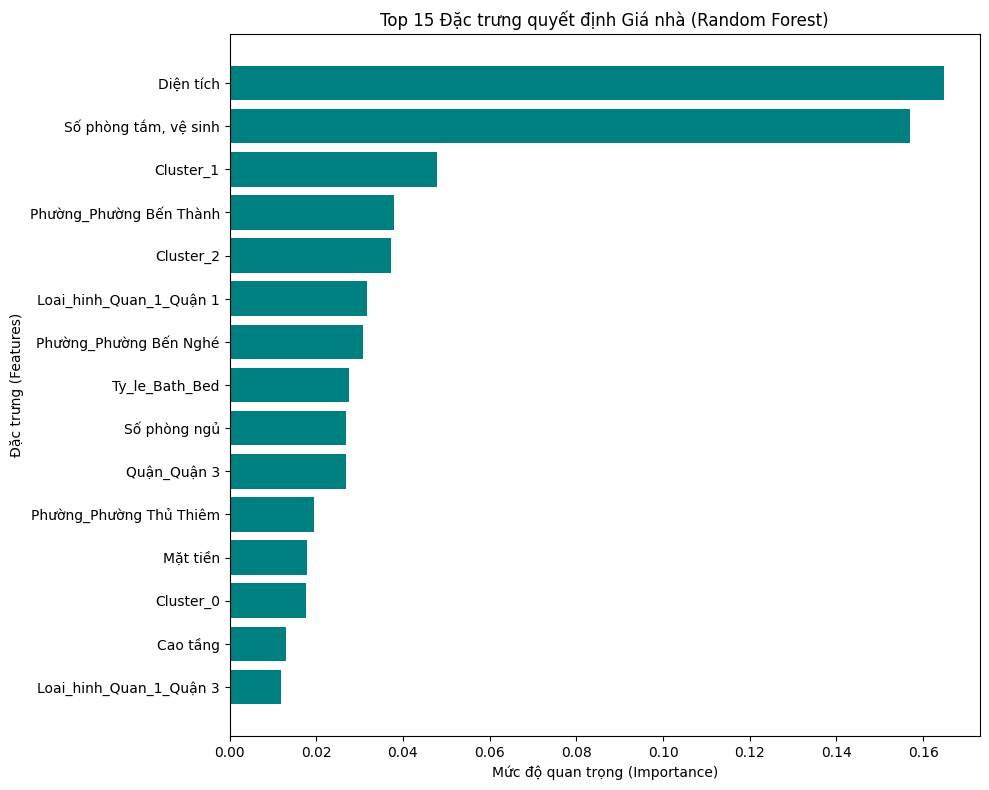

                     Feature  Importance
0                  Diện tích    0.164882
2      Số phòng tắm, vệ sinh    0.156964
83                 Cluster_1    0.047874
132  Phường_Phường Bến Thành    0.037904
84                 Cluster_2    0.037138
68   Loai_hinh_Quan_1_Quận 1    0.031704
131   Phường_Phường Bến Nghé    0.030806
3             Ty_le_Bath_Bed    0.027514
1               Số phòng ngủ    0.026875
28               Quận_Quận 3    0.026795
174  Phường_Phường Thủ Thiêm    0.019546
4                   Mặt tiền    0.017793
82                 Cluster_0    0.017662
5                   Cao tầng    0.012989
69   Loai_hinh_Quan_1_Quận 3    0.011772


In [ ]:
import matplotlib.pyplot as plt

ohe_cols = rf_pipeline.named_steps['preprocessor'].named_transformers_['cat'].get_feature_names_out(cat_cols)
feature_names = num_cols + list(ohe_cols)

importances = rf_pipeline.named_steps['model'].feature_importances_

fi_df = pd.DataFrame({'Feature': feature_names, 'Importance': importances})
fi_df = fi_df.sort_values(by='Importance', ascending=False).head(15)

plt.figure(figsize=(10, 8))
plt.barh(fi_df['Feature'][::-1], fi_df['Importance'][::-1], color='teal')
plt.xlabel('Mức độ quan trọng (Importance)')
plt.ylabel('Đặc trưng (Features)')
plt.title('Top 15 Đặc trưng quyết định Giá nhà (Random Forest)')
plt.tight_layout()
plt.show()

print(fi_df)

#10. Tinh chỉnh siêu tham số cho Random Forest

In [ ]:
from sklearn.model_selection import RandomizedSearchCV

rf_param_dist = {
    'model__n_estimators': [100, 200, 300],
    'model__max_depth': [None, 10, 20, 30],
    'model__min_samples_split': [2, 5, 10],
    'model__min_samples_leaf': [1, 2, 4]
}

rf_random_search = RandomizedSearchCV(
    estimator=rf_pipeline,
    param_distributions=rf_param_dist,
    n_iter=10, # Thử nghiệm ngẫu nhiên 10 tổ hợp tham số
    cv=3,      # Cross-validation 3 folds
    scoring='neg_mean_absolute_error',
    random_state=42,
    n_jobs=-1
)

rf_random_search.fit(X_train, y_train)

print("Tham số tốt nhất cho Random Forest:")
print(rf_random_search.best_params_)

Tham số tốt nhất cho Random Forest:
{'model__n_estimators': 200, 'model__min_samples_split': 5, 'model__min_samples_leaf': 1, 'model__max_depth': None}


# 11. Tinh chỉnh siêu tham số cho XGBoost

In [ ]:
xgb_param_dist = {
    'model__n_estimators': [100, 200, 300],
    'model__learning_rate': [0.01, 0.05, 0.1, 0.2],
    'model__max_depth': [3, 5, 7, 9],
    'model__subsample': [0.7, 0.8, 0.9, 1.0],
    'model__colsample_bytree': [0.7, 0.8, 0.9, 1.0]
}

xgb_random_search = RandomizedSearchCV(
    estimator=xgb_pipeline,
    param_distributions=xgb_param_dist,
    n_iter=15,
    cv=3,
    scoring='neg_mean_absolute_error',
    random_state=42,
    n_jobs=-1
)

xgb_random_search.fit(X_train, y_train)

print("Tham số tốt nhất cho XGBoost:")
print(xgb_random_search.best_params_)

Tham số tốt nhất cho XGBoost:
{'model__subsample': 0.7, 'model__n_estimators': 300, 'model__max_depth': 9, 'model__learning_rate': 0.05, 'model__colsample_bytree': 1.0}


# 12. Đánh giá mô hình sau khi Tối ưu (Tuned Models)

In [ ]:
best_rf_model = rf_random_search.best_estimator_
best_xgb_model = xgb_random_search.best_estimator_

print("KẾT QUẢ ĐÁNH GIÁ SAU KHI TUNING:\n")
evaluate_model("Random Forest (Tuned)", best_rf_model, X_test, y_test)
evaluate_model("XGBoost (Tuned)", best_xgb_model, X_test, y_test)

KẾT QUẢ ĐÁNH GIÁ SAU KHI TUNING:

--- Random Forest (Tuned) ---
RMSE : 0.0670
MAE  : 0.0373
R2   : 0.6820

--- XGBoost (Tuned) ---
RMSE : 0.0656
MAE  : 0.0375
R2   : 0.6950



# 13. Lưu mô hình

In [ ]:
import joblib

joblib.dump(best_rf_model, 'best_rf_model.pkl')

joblib.dump(best_xgb_model, 'best_xgb_model.pkl')

print("Đã lưu thành công các mô hình ra file .pkl!")

Đã lưu thành công các mô hình ra file .pkl!
